# 07 Answer Relevancy Evaluator

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `07-answer-relevancy-evaluator.ipynb`

In [2]:
# ==========================================
# Notebook 07
# Answer Relevancy Evaluator
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [4]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [5]:
question = "What is AWS?"

answer = "AWS is Amazon Web Services, a cloud platform."

In [6]:
question_embedding = embedding_model.encode(question)

answer_embedding = embedding_model.encode(answer)

In [7]:
similarity = cosine_similarity(
    question_embedding.reshape(1, -1), answer_embedding.reshape(1, -1)
)[0][0]

In [8]:
print(f"Relevancy Score: {similarity:.4f}")

Relevancy Score: 0.8128


In [9]:
def answer_relevancy_score(question, answer, model):

    q_emb = model.encode(question)

    a_emb = model.encode(answer)

    similarity = cosine_similarity(q_emb.reshape(1, -1), a_emb.reshape(1, -1))[0][0]

    return float(similarity)

In [10]:
answer_relevancy_score(question, answer, embedding_model)

0.8128139972686768

In [11]:
bad_answer = """
Azure is Microsoft's cloud platform.

Google Cloud provides storage.

Oracle Cloud supports databases.
"""

In [12]:
answer_relevancy_score(question, bad_answer, embedding_model)

0.2816701829433441

In [13]:
relevancy_scores = []

In [14]:
for _, row in df.iterrows():

    score = answer_relevancy_score(
        row["question"], row["generated_response"], embedding_model
    )

    relevancy_scores.append(score)

In [15]:
relevancy_df = pd.DataFrame({"answer_relevancy": relevancy_scores})

In [16]:
relevancy_df.head()

,answer_relevancy
0,0.771484
1,0.859219
2,0.773407
3,0.700566
4,0.773966


In [17]:
evaluation_df = pd.concat([df, relevancy_df], axis=1)

In [18]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,answer_relevancy
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0.771484
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0.859219
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0.773407
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0.700566
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0.773966


In [19]:
evaluation_df["answer_relevancy"].mean()

0.4147055070847273

In [20]:
def relevancy_label(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [21]:
evaluation_df["relevancy_quality"] = evaluation_df["answer_relevancy"].apply(
    relevancy_label
)

In [22]:
evaluation_df[["question", "answer_relevancy", "relevancy_quality"]]

,question,answer_relevancy,relevancy_quality
0,What is AWS?,0.771484,Average
1,What is Azure?,0.859219,Good
2,What is Google Cloud?,0.773407,Average
3,What is AWS?,0.700566,Average
4,What is Azure?,0.773966,Average
5,What is Google Cloud?,0.811333,Good
6,What is Oracle Cloud?,0.848702,Good
7,What is IBM Cloud?,0.862217,Good
8,Question 8,0.132426,Poor
9,Question 9,0.115511,Poor


In [23]:
evaluation_df["answer_length"] = evaluation_df["generated_response"].str.len()

In [24]:
evaluation_df[["answer_length", "answer_relevancy"]].corr()

,answer_length,answer_relevancy
answer_length,1.000000,0.928177
answer_relevancy,0.928177,1.000000


In [25]:
low_relevancy = evaluation_df[evaluation_df["answer_relevancy"] < 0.70]

In [26]:
low_relevancy[["question", "generated_response", "answer_relevancy"]]

,question,generated_response,answer_relevancy
8,Question 8,Sample generated response,0.132426
9,Question 9,Sample generated response,0.115511
10,Question 10,Sample generated response,0.122226
11,Question 11,Sample generated response,0.139133
12,Question 12,Sample generated response,0.126529
13,Question 13,Sample generated response,0.169237
14,Question 14,Sample generated response,0.163706
15,Question 15,Sample generated response,0.162117
16,Question 16,Sample generated response,0.154724
17,Question 17,Sample generated response,0.183739


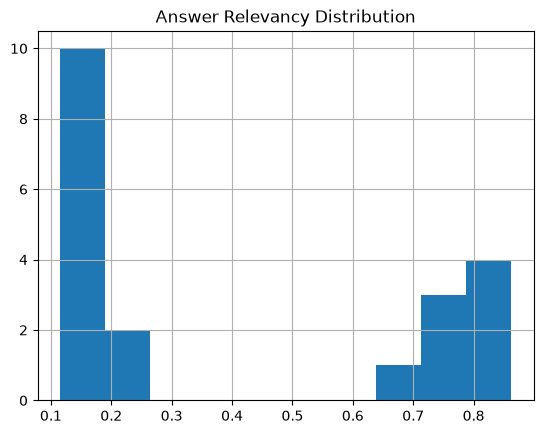

In [27]:
evaluation_df["answer_relevancy"].hist(bins=10)

plt.title("Answer Relevancy Distribution")

plt.show()

In [28]:
faithfulness_df = pd.read_csv("../evaluation_results/faithfulness_results.csv")

In [29]:
rag_metrics = pd.DataFrame(
    {
        "faithfulness": faithfulness_df["faithfulness"],
        "answer_relevancy": evaluation_df["answer_relevancy"],
    }
)

In [30]:
rag_metrics.head()

,faithfulness,answer_relevancy
0,1.0,0.771484
1,1.0,0.859219
2,1.0,0.773407
3,1.0,0.700566
4,1.0,0.773966


In [31]:
rag_metrics.corr()

,faithfulness,answer_relevancy
faithfulness,1.000000,0.991561
answer_relevancy,0.991561,1.000000


In [32]:
def rag_status(faithfulness, relevancy):

    if faithfulness >= 0.80 and relevancy >= 0.80:

        return "Healthy"

    if faithfulness >= 0.80 and relevancy < 0.80:

        return "Off Topic"

    if faithfulness < 0.80 and relevancy >= 0.80:

        return "Hallucinating"

    return "Poor"

In [33]:
combined_df = pd.DataFrame(
    {
        "faithfulness": faithfulness_df["faithfulness"],
        "answer_relevancy": evaluation_df["answer_relevancy"],
    }
)

In [34]:
combined_df["rag_status"] = combined_df.apply(
    lambda row: rag_status(row["faithfulness"], row["answer_relevancy"]), axis=1
)

In [35]:
combined_df.head()

,faithfulness,answer_relevancy,rag_status
0,1.0,0.771484,Off Topic
1,1.0,0.859219,Healthy
2,1.0,0.773407,Off Topic
3,1.0,0.700566,Off Topic
4,1.0,0.773966,Off Topic


In [36]:
evaluation_df.to_csv("../evaluation_results/answer_relevancy_results.csv", index=False)